# classifier

In [20]:
import time as t
import os
import numpy as np
from ultralytics import YOLO
from glob import glob
import cv2
import json
import yaml
import tqdm as tqdm
from pathlib import Path
import matplotlib.pyplot as plt 

from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image, scale_cam_image

## config 

In [ ]:
dataset_dir = "../datasets/"
dataset_path = Path(dataset_dir)
cls_dataset_dir = dataset_path / "AllSpecies-cls"
groups = ["Coleoptera", "Hymenoptera", "Lepidoptera"]
config_file = "yolo26n-cls.pt"


# label preparation

In [22]:
label_dict = {name:list(dataset_path.rglob(f"{name}/**/*.png")) + list(dataset_path.rglob(f"{name}/**/*.jpg")) for name in groups}
for x in label_dict.items():
    print(f"{x[0]}: {len(x[1])} images")

all_test_images  =[img for img in cls_dataset_dir.rglob("**/*.png") if "test" in img.parts] + [img for img in cls_dataset_dir.rglob("**/*.jpg") if "test" in img.parts]
print(f"Total test images: {len(all_test_images)}")

Coleoptera: 1672 images
Hymenoptera: 386 images
Lepidoptera: 772 images
Total test images: 291


## YOLO loading

In [5]:
model = YOLO(config_file)

# to load a model from a previous training run, use the path to the best.pt file in the runs/train/exp directory
# model = YOLO("runs/train/exp/weights/best.pt")


# training

In [6]:
results = model.train(data=cls_dataset_dir, epochs=1, imgsz=640)

New https://pypi.org/project/ultralytics/8.4.58 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.27  Python-3.14.0 torch-2.11.0+cpu CPU (Intel Core i7-1065G7 1.30GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\datasets\AllSpecies-cls, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=6

## evaluation metrics

In [ ]:
# create confusion matrix with test results
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tqdm 

y_true = []
y_pred = []

for img in tqdm.tqdm(all_test_images):
    true_label = img.parts[-2]  # Assuming the folder name is the class label
    y_true.append(true_label)
    
    result = model(str(img), conf=0.25)[0]
    
    y_pred.append(groups[result.probs.data.argmax().item()])  # Get the predicted class index

  0%|          | 0/145 [00:00<?, ?it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-cls\test\Coleoptera\IMG_0109_specimen_3_MECKON_NEON.BET.D20.000026.png: 640x640 Coleoptera 1.00, Hymenoptera 0.00, Lepidoptera 0.00, 92.4ms
Speed: 26.7ms preprocess, 92.4ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)


  1%|          | 1/145 [00:00<00:19,  7.37it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-cls\test\Coleoptera\IMG_0115_specimen_2_MECKON_NEON.BET.D20.000146.png: 640x640 Coleoptera 1.00, Hymenoptera 0.00, Lepidoptera 0.00, 67.9ms
Speed: 22.1ms preprocess, 67.9ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)


  1%|▏         | 2/145 [00:00<00:18,  7.81it/s]

...

 99%|█████████▊| 143/145 [00:31<00:01,  1.74it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-cls\test\Lepidoptera\F.39791.jpg: 640x640 Lepidoptera 1.00, Hymenoptera 0.00, Coleoptera 0.00, 89.4ms
Speed: 270.9ms preprocess, 89.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)


 99%|█████████▉| 144/145 [00:31<00:00,  1.74it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-cls\test\Lepidoptera\F.41741.jpg: 640x640 Lepidoptera 1.00, Hymenoptera 0.00, Coleoptera 0.00, 67.1ms
Speed: 239.5ms preprocess, 67.1ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)


100%|██████████| 145/145 [00:32<00:00,  4.47it/s]


In [19]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot().figure_.savefig('classification_confusion_matrix.png')
disp.plot()

## attention


0: 640x640 Lepidoptera 0.95, Hymenoptera 0.05, Coleoptera 0.00, 166.8ms
Speed: 71.4ms preprocess, 166.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


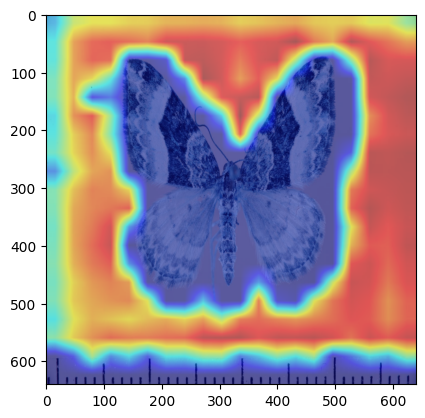

In [ ]:
model = YOLO("./runs/classify/train3/weights/best.pt") 
model = model.cpu()

target_layers = [model.model.model[-3]]

img = cv2.imread('images/lepidoptera.jpg')
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

cam = EigenCAM(model, target_layers, task='cls')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.savefig('classification_cam.png')
plt.show()

# loading with background

In [23]:
model_bg = YOLO(config_file)

# training with background

In [25]:
results = model_bg.train(data=cls_dataset_dir, epochs=1, imgsz=640)

New https://pypi.org/project/ultralytics/8.4.59 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.27  Python-3.14.0 torch-2.11.0+cpu CPU (Intel Core i7-1065G7 1.30GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\datasets\AllSpecies-cls, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=

## metrics

In [26]:
# create confusion matrix with test results
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tqdm 

y_true = []
y_pred = []

for img in tqdm.tqdm(all_test_images):
    true_label = img.parts[-2]  # Assuming the folder name is the class label
    y_true.append(true_label)
    
    result = model(str(img), conf=0.25)[0]
    
    y_pred.append(groups[result.probs.data.argmax().item()])  # Get the predicted class index

  0%|          | 0/291 [00:00<?, ?it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-cls\test\background\IMG_0109_specimen_2_MECKON_NEON.BET.D20.000017.png: 640x640 Hymenoptera 0.54, Lepidoptera 0.35, Coleoptera 0.11, 152.6ms
Speed: 26.4ms preprocess, 152.6ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)


  0%|          | 1/291 [00:00<01:02,  4.66it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-cls\test\background\IMG_0109_specimen_3_MECKON_NEON.BET.D20.000026.png: 640x640 Lepidoptera 0.48, Hymenoptera 0.41, Coleoptera 0.11, 84.3ms
Speed: 22.6ms preprocess, 84.3ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)


  1%|          | 2/291 [00:00<00:49,  5.88it/s]

...

 99%|█████████▉| 289/291 [01:04<00:01,  1.95it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-cls\test\Lepidoptera\F.39791.jpg: 640x640 Lepidoptera 1.00, Hymenoptera 0.00, Coleoptera 0.00, 62.4ms
Speed: 221.9ms preprocess, 62.4ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)


100%|█████████▉| 290/291 [01:04<00:00,  1.98it/s]


image 1/1 c:\Users\tombe\Documents\_MLE\CV-for-GRIT\models\classifier\..\datasets\AllSpecies-cls\test\Lepidoptera\F.41741.jpg: 640x640 Lepidoptera 1.00, Hymenoptera 0.00, Coleoptera 0.00, 78.9ms
Speed: 244.5ms preprocess, 78.9ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)


100%|██████████| 291/291 [01:05<00:00,  4.45it/s]


In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot().figure_.savefig('classification_background_confusion_matrix.png')
disp.plot()

# attention with background

In [ ]:
model = YOLO("./runs/classify/train4/weights/best.pt") 
model = model.cpu()

target_layers = [model.model.model[-3]]

img = cv2.imread('images/lepidoptera.jpg')
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

cam = EigenCAM(model, target_layers, task='cls')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.savefig('classification_background_cam.png')
plt.show()


0: 640x640 Lepidoptera 1.00, background 0.00, Hymenoptera 0.00, Coleoptera 0.00, 83.9ms
Speed: 11.4ms preprocess, 83.9ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 640x480 with 1 Axes>